In [ ]:
# -*- coding: utf-8 -*-
from dreal import *
from Functions import *
import torch as th
import torch.nn.functional as F
import numpy as np
import timeit 
from matplotlib import cm
import matplotlib.pyplot as plt
# %matplotlib notebook

device = th.device("cuda" if th.cuda.is_available() else "cpu")
print(f"Using device: {device}") ## device should be cuda 

Using device: cuda


In [2]:
class Learner(th.nn.Module):
    
    def __init__(self,n_input,n_hidden,n_output, controller=False, lqr=None, multi=False):
        super(Learner, self).__init__()
        # th.manual_seed(2)
        self.layer1 = th.nn.Linear(n_input, n_hidden)
        self.activation1 = th.nn.Tanh()
        self.layer2 = th.nn.Linear(n_hidden,n_output)
        self.activation2 = th.nn.Tanh()

        self.controller = controller
        if self.controller:

            if lqr is None: raise ValueError("Input controller initialization")

            self.control = th.nn.Linear(n_input,1,bias=False)
            self.control.weight = th.nn.Parameter(lqr)

        self.multi = multi
        if self.multi:
            self.layer1_2 = th.nn.Linear(n_input, n_hidden)
            self.activation1_2 = th.nn.Tanh()
            self.layer2_2 = th.nn.Linear(n_hidden,n_output)
            self.activation2_2 = th.nn.Tanh()

    def forward(self,x, primary=True):

        if primary:
            h_1 = self.activation1(self.layer1(x))
            out = self.activation2(self.layer2(h_1))
        elif self.multi:
            h_1 = self.activation1_2(self.layer1_2(x))
            out = self.activation2_2(self.layer2_2(h_1))
        else:
            assert TypeError('Multiple Lyapunov function not active')

        if self.controller:
            u = self.control(x)
            return out,u
        
        else:
            return out

In [3]:
# A1 = [[-1, -1], [5, -2]]
# A2 = [[-2, -4], [20, -2]]

# A1 = [[-1, -1], [1, -1]]
# A2 = [[-1, -10], [0.1, -1]]

# B = [[0], [0]]

A1 = [[-1, 0], [0, -1]]
A2 = [[-1, 0], [0, -1]]

B = [[1], [1]]


def f_auto(x):
    #Dynamics
    y = th.zeros(x.shape, device=x.device)
    
    A1_ = th.tensor(A1, dtype=th.float32, device=x.device)
    A2_ = th.tensor(A2, dtype=th.float32, device=x.device)

    
    for r in range(0,len(x)): 

        if x[r][1] <= 0: # x_1 <= 0
            # f = A1 @ x[r]
            y[r] = A1_ @ x[r]
        else: # x_1 > 0
            # f = A2 @ x[r]
            y[r] = A2_ @ x[r]

        # y.append(f) 

    # print(y)
    # y = th.stack(y).to(x.device)
    return y


def f_manu(x, u):
    #Dynamics
    # y = th.zeros(x.shape, device=x.device)
    
    # A1_ = th.tensor(A1, dtype=th.float32, device=x.device)
    # A2_ = th.tensor(A2, dtype=th.float32, device=x.device)
    # B_ = th.tensor(B, dtype=th.float32, device=x.device).squeeze()
    
    # for r in range(0,len(x)): 

    #     if x[r][1] <= 0: # x_1 <= 0
    #         # f = A1 @ x[r]
    #         y[r] = A1_ @ x[r] + B_*u[r]
    #     else: # x_1 > 0
    #         # f = A2 @ x[r]
    #         # print(y.shape)
    #         y[r] = A2_ @ x[r] + B_*u[r]

        # y.append(f) 

    # print(y)
    # y = th.stack(y).to(x.device)

    y = []
    G = 9.81  # gravity
    L = 0.5   # length of the pole 
    m = 0.15  # ball mass
    # b = 0.2   # friction

    x_ = x.cpu()
    
    for r in range(0,len(x_)): 
        
        if x_[r][0] <= 0:
            b = 0.1
        else:
            b = 0.2

        f = [ x_[r][1], 
              (m*G*L*np.sin(x_[r][0])- b*x_[r][1]) / (m*L**2)]
        y.append(f) 
    y = torch.tensor(y, device=x.device)
    y[:,1] = y[:,1] + (u[:,0]/(m*L**2))
    return y



lqr = torch.tensor([[-23.58639732,  -5.31421063]], dtype=torch.float32, device=device) 

In [4]:
'''
For learning 
'''
N = 500             # sample size
D_in = 2            # input dimension
H1 = 6              # hidden dimension
D_out = 1           # output dimension
# th.manual_seed(10)  
x = th.Tensor(N, D_in).uniform_(-6, 6).to(dtype=th.float32, device=device)
x_0 = th.zeros([1, 2], dtype=th.float32, device=device)


'''
For verifying 
'''
G = 9.81 
l = 0.5  
m = 0.15
b1 = 0.1
b2 = 0.2


x1 = Variable("x1")
x2 = Variable("x2")
vars_ = [x1,x2]
switch_cond = x1 <= 0
config = Config()
config.use_polytope_in_forall = True
config.use_local_optimization = True
config.precision = 1e-2
epsilon = 0
# Checking candidate V within a ball around the origin (ball_lb ≤ sqrt(∑xᵢ²) ≤ ball_ub)
ball_lb = 0.5
ball_ub = 6

## Learning and Falsification

In [5]:
out_iters = 0
valid = False
TRIES = 2
MAX_ITERS = 2000

lyap_risks = np.zeros((TRIES, MAX_ITERS))

while out_iters < TRIES and not valid: 
    start = timeit.default_timer()
    
    model = Learner(D_in, H1, D_out, controller=True, lqr=lqr, multi=True).to(device)
    L = []
    i = 0 
    t = 0
    
    # learning_rate = 0.01
    learning_rate = 0.01
    # optimizer = th.optim.Adam(model.parameters(), lr=learning_rate)
    optimizer = torch.optim.RMSprop(model.parameters(), lr=0.01, alpha=0.99, eps=1e-8, weight_decay=1e-4)

    while i < MAX_ITERS and not valid: 

        # split training set into regions
        X1 = x[x[:, 0] <= 0]
        X2 = x[x[:, 0] > 0]

        V_candidate_1, u_1 = model(X1, True)
        X0_1, u0_1 = model(x_0, True)

        V_candidate_2, u_2 = model(X2, False)
        X0_2, u0_2 = model(x_0, False)
        
        f_1 = f_manu(X1, u_1)
        f_2 = f_manu(X2, u_2)


        # Compute lie derivative of V : L_V = ∑∂V/∂xᵢ*fᵢ
        L_v_1 = th.diagonal(th.mm(th.mm(th.mm(dtanh(V_candidate_1),model.layer2.weight)\
                            *dtanh(th.tanh(th.mm(X1,model.layer1.weight.t())+model.layer1.bias)),model.layer1.weight),f_1.t()),0)
        
        L_v_2 = th.diagonal(th.mm(th.mm(th.mm(dtanh(V_candidate_2),model.layer2_2.weight)\
                            *dtanh(th.tanh(th.mm(X2,model.layer1_2.weight.t())+model.layer1_2.bias)),model.layer1_2.weight),f_2.t()),0)
        
        # With tuning term 
        # Circle_Tuning = Tune(x)
        # Lyapunov_risk = (F.relu(-V_candidate)+ 1.5*F.relu(L_V+0.5)).mean()\
        #             +2.2*((Circle_Tuning-6*V_candidate).pow(2)).mean()+(X0).pow(2) 

        # Without tuning term
        Lyapunov_risk = (F.relu(-V_candidate_1) + 1.5*F.relu(L_v_1 + 0.5)).mean() + (X0_1).pow(2)
        Lyapunov_risk += (F.relu(-V_candidate_2) + 1.5*F.relu(L_v_2 + 0.5)).mean() + (X0_2).pow(2)

        # Lyapunov_risk = (F.relu(-V_candidate)).mean() + (1.5*F.relu(L_V+0.5)).mean()+ 1.2*(X0).pow(2)
        
        
        print(i, "Lyapunov Risk=",Lyapunov_risk.item()) 
        L.append(Lyapunov_risk.item())
        lyap_risks[out_iters, i] = Lyapunov_risk.item()
        optimizer.zero_grad()
        Lyapunov_risk.backward()
        optimizer.step() 

        w1_1 = model.layer1.weight.data.cpu().numpy()
        w2_1 = model.layer2.weight.data.cpu().numpy()
        b1_1 = model.layer1.bias.data.cpu().numpy()
        b2_1 = model.layer2.bias.data.cpu().numpy()
        q = model.control.weight.data.cpu().numpy()

        w1_2 = model.layer1_2.weight.data.cpu().numpy()
        w2_2 = model.layer2_2.weight.data.cpu().numpy()
        b1_2 = model.layer1_2.bias.data.cpu().numpy()
        b2_2 = model.layer2_2.bias.data.cpu().numpy()

        # Falsification
        if i % 10 == 0:
            u_NN = (q.item(0)*x1 + q.item(1)*x2) 

            f1 = [ x2,
                 (m*G*l*sin(x1) + u_NN - b1*x2) /(m*l**2)]
            
            f2 = [ x2,
                 (m*G*l*sin(x1) + u_NN - b2*x2) /(m*l**2)]
            
            # f1 = np.dot(A1-B@q, vars_)
            # f2 = np.dot(A2-B@q, vars_)
            
            # Candidate V_1
            z1_1 = np.dot(vars_,w1_1.T)+b1_1

            a1_1 = []
            for j in range(0,len(z1_1)):
                a1_1.append(tanh(z1_1[j]))
            z2_1 = np.dot(a1_1,w2_1.T)+b2_1
            V_learn_1 = tanh(z2_1.item(0))

            # Candidate V_2
            z1_2 = np.dot(vars_,w1_2.T)+b1_2

            a1_2 = []
            for j in range(0,len(z1_2)):
                a1_2.append(tanh(z1_2[j]))
            z2_2 = np.dot(a1_2,w2_2.T)+b2_2
            V_learn_2 = tanh(z2_2.item(0))


            print('===========Verifying==========')        
            start_ = timeit.default_timer() 
            # result = CheckLyapunov(vars_, f, V_learn, ball_lb, ball_ub, config,epsilon)
            # 'LP' for relaxing Lyapunov function 
            # 'LD' for relaxing Lie Derivatie
            result = CheckLyapunovMultiple(vars_, f1, f2, switch_cond, V_learn_1, V_learn_2, ball_lb, ball_ub, config,epsilon)
            # result2 = CheckLyapunov(vars_, f1, V_learn_1, ball_lb, ball_ub, config,epsilon)
            # result3 = CheckLyapunov(vars_, f2, V_learn_2, ball_lb, ball_ub, config,epsilon)

            stop_ = timeit.default_timer() 



            if (result): 
                print("Not a Lyapunov function. Found counterexample: ")
                print(result)
                # x = resample_location(x)
                x = AddCounterexamples(x,result,15).to(th.float32)
            else:  
                valid = True
                print("Satisfy conditions!!")
                # print(f'Multi V = {result}, V1 = {result2}, V2 = {result3}')
                print(V_learn_1, "on x_1 <= 0 ", V_learn_2, " on x_1 > 0 are Lyapunov functions.")
            t += (stop_ - start_)
            print('==============================') 
        i += 1

    stop = timeit.default_timer()


    # np.savetxt("w1.txt", model.layer1.weight.data, fmt="%s")
    # np.savetxt("w2.txt", model.layer2.weight.data, fmt="%s")
    # np.savetxt("b1.txt", model.layer1.bias.data, fmt="%s")
    # np.savetxt("b2.txt", model.layer2.bias.data, fmt="%s")
    # np.savetxt("q.txt", model.control.weight.data, fmt="%s")

    print('\n')
    print("Total time: ", stop - start)
    print("Verified time: ", t)
    print(f"Lyapunov Function found: {valid}")
    
    out_iters+=1


/tmp/ipykernel_24299/3906086529.py:78: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  (m*G*L*np.sin(x_[r][0])- b*x_[r][1]) / (m*L**2)]


0 Lyapunov Risk= 271.4378356933594
===========Verifying==========
Not a Lyapunov function. Found counterexample: 
x1 : [-0.89239261540101278, -0.88239261540101277]
x2 : [5.4030877811845812, 5.413087781184581]
1 Lyapunov Risk= 12.959714889526367
2 Lyapunov Risk= 2.261730194091797
3 Lyapunov Risk= 2.140690326690674
4 Lyapunov Risk= 2.044252395629883
5 Lyapunov Risk= 1.9731323719024658
6 Lyapunov Risk= 1.9105224609375
7 Lyapunov Risk= 1.83162260055542
8 Lyapunov Risk= 1.7509689331054688
9 Lyapunov Risk= 1.6663752794265747
10 Lyapunov Risk= 1.5772616863250732
===========Verifying==========
Not a Lyapunov function. Found counterexample: 
x1 : [2.1085860088190751, 2.1094503105344868]
x2 : [-5.616558100761492, -5.6158334915810624]
11 Lyapunov Risk= 1.5515491962432861
12 Lyapunov Risk= 1.473366379737854
13 Lyapunov Risk= 1.413461685180664
14 Lyapunov Risk= 1.3652143478393555
15 Lyapunov Risk= 1.3370554447174072
16 Lyapunov Risk= 1.3009716272354126
17 Lyapunov Risk= 1.2521882057189941
18 Lyapun

In [6]:
print(V_learn_1, "on x_1 <= 0 ")
print(V_learn_2, " on x_1 > 0")

tanh((0.29501590132713318 - 0.02038218267261982 * tanh((-0.43410822749137878 + 0.47718295454978943 * x1 - 0.12102217227220535 * x2)) + 0.23894144594669342 * tanh((-0.22011658549308777 - 0.11342794448137283 * x1 - 0.67993003129959106 * x2)) + 0.71891039609909058 * tanh((0.037875518202781677 - 2.1689777374267578 * x1 + 0.050627566874027252 * x2)) - 0.1663798987865448 * tanh((0.11773142218589783 - 0.00065439898753538728 * x1 - 0.88873279094696045 * x2)) - 0.0057000834494829178 * tanh((0.61295408010482788 - 0.32621333003044128 * x1 + 0.1970769464969635 * x2)) - 0.36267590522766113 * tanh((0.87998366355895996 + 0.26332679390907288 * x1 + 0.24591915309429169 * x2)))) on x_1 <= 0 
tanh((0.31063371896743774 + 0.056913439184427261 * tanh((-0.96565639972686768 + 0.3683600127696991 * x1 + 1.0422035455703735 * x2)) + 0.2145446389913559 * tanh((-0.91593432426452637 - 2.4367706775665283 * x1 - 0.35633647441864014 * x2)) + 0.44392132759094238 * tanh((-0.4305415153503418 + 1.7560626268386841 * x1 + 0.

In [7]:
# evaluate counter example

ce = np.array([result[0].mid(), result[1].mid()])
# ce = np.array([4.6789, -2.6081])
# ce = np.array([result[0].lb(), result[1].lb()])

if ce[0] <= 0:
    print('x1 <= 0')
    # f = np.dot(A1-B@q, ce)
    f = [ ce[1],
      (m*G*l*np.sin(ce[0]) + np.dot(q, ce).squeeze() - b1*ce[1]) /(m*l**2)]

    # Lyapunov function
    lf = np.tanh(np.dot(np.tanh(np.dot(ce, w1_1.T) + b1_1), w2_1.T) + b2_1)

    # Lie Derivative
    ld = np.matmul( np.matmul( np.matmul(dtanh(lf), w2_1) * dtanh(np.tanh(np.matmul(ce,w1_1.T)+b1_1)),w1_1 ),f.T )

    # Origin value 
    v0 = np.tanh(np.dot(np.tanh(np.dot(np.zeros(2), w1_1.T) + b1_1), w2_1.T) + b2_1)

else:
    print('x1 > 0')
    # f = np.dot(A2-B@q, ce)
    f = [ ce[1],
      (m*G*l*np.sin(ce[0]) + np.dot(q, ce).squeeze() - b2*ce[1]) /(m*l**2)]

    # Lyapunov function
    lf = np.tanh(np.dot(np.tanh(np.dot(ce, w1_2.T) + b1_2), w2_2.T) + b2_2)

    # Lie Derivative
    ld = np.matmul( np.matmul( np.matmul(dtanh(lf), w2_2) * dtanh(np.tanh(np.matmul(ce,w1_2.T)+b1_2)),w1_2 ),f.T )

    # Origin value 
    v0 = np.tanh(np.dot(np.tanh(np.dot(np.zeros(2), w1_2.T) + b1_2), w2_2.T) + b2_2)





print("Constraints: V(.) > 0, dV(.) < 0, V(0) = 0")
print(f'Counter Example: V(x) = {lf.item():.2f}, dV(x) = {ld.item():.2f}, v0 = {v0.item():.2f}')

TypeError: 'NoneType' object is not subscriptable

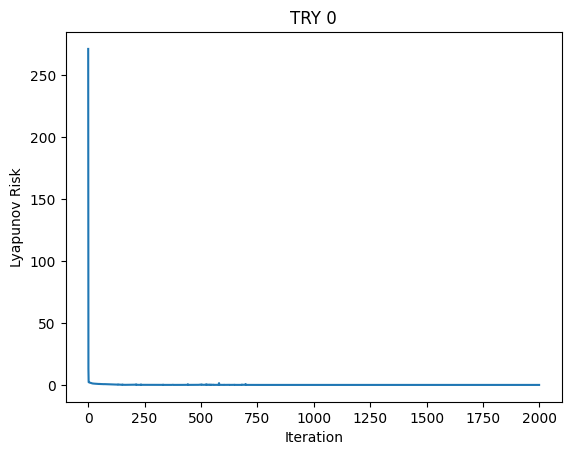

In [8]:
# for i in range(out_iters):

#     plt.figure()
#     plt.plot(lyap_risks[i, :])
#     plt.title(f'TRY {i}')
#     plt.xlabel('Iteration')
#     plt.ylabel('Lyapunov Risk')
#     plt.show()

start = 0
for i in range(out_iters):

    plt.figure()
    plt.plot(range(start, 2000), lyap_risks[i, start:])
    plt.title(f'TRY {i}')
    plt.xlabel('Iteration')
    plt.ylabel('Lyapunov Risk')
    plt.show()


In [97]:
# plot V


X = th.linspace(-6, 6, 100) 
Y = th.linspace(-6, 6, 100)
x1, x2 = np.meshgrid(X.numpy(),Y.numpy())

K = model.control.weight.data.cpu()

X_plot = th.stack([th.tensor(x1.flatten()), th.tensor(x2.flatten())]).T
u_plot = (X_plot @ K.T)

In [98]:
y_plot = f_manu(X_plot, u_plot)


/tmp/ipykernel_24299/3906086529.py:78: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  (m*G*L*np.sin(x_[r][0])- b*x_[r][1]) / (m*L**2)]


In [99]:
# plot V


V_plot_1, u_plot_1 = model(X_plot.to(device=device))
V_plot_2, u_plot_2 = model(X_plot.to(device=device), False)
# V_plot_cpu = V_plot.reshape(100, 100).cpu().detach().numpy()




V_plot = th.zeros(100*100)
for i, x in enumerate(X_plot):

    if x[0] <= 0:
        V_plot[i] = V_plot_1[i]
    
    else:
        V_plot[i] = V_plot_2[i]

    
V_plot = V_plot.reshape(100, 100).cpu().detach().numpy()



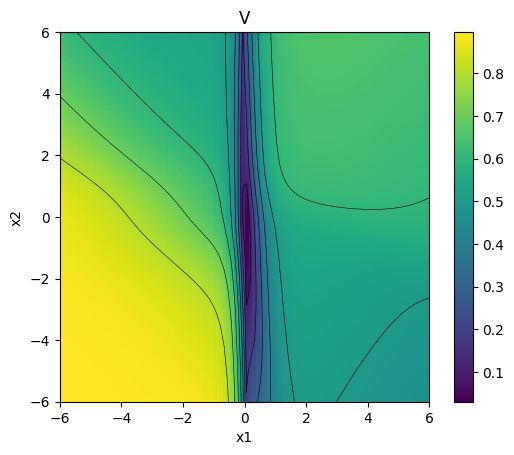

In [134]:
plt.imshow(V_plot, extent=[-6, 6, -6, 6], origin='lower')
plt.colorbar(cmap=cm.coolwarm)
plt.title('V')
plt.xlabel('x1')
plt.ylabel('x2')
# plt.xticks(ticks=range(100), labels=X)
plt.contour(x1,x2,V_plot,8,linewidths=0.4, colors='k')
plt.show()

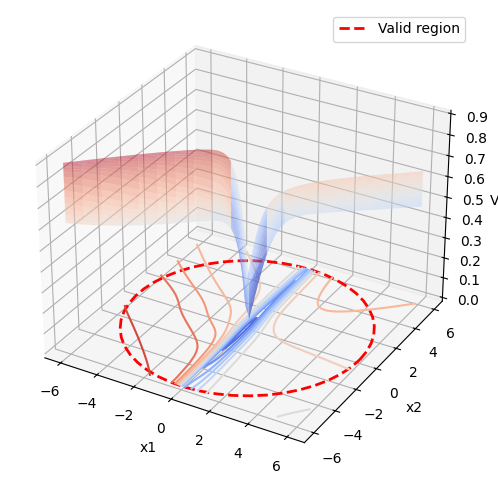

In [101]:

fig = plt.figure(figsize=(6, 6))
plt.tight_layout()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X,Y,V_plot, rstride=5, cstride=5, alpha=0.5, cmap=cm.coolwarm)
ax.contour(X,Y,V_plot,10, zdir='z', offset=0, cmap=cm.coolwarm)

# Plot Valid region computed by dReal
r=6
theta = np.linspace(0,2*np.pi,50)
xc = r*np.cos(theta)
yc = r*np.sin(theta)
ax.plot(xc[:],yc[:],'r',linestyle='--', linewidth=2 ,label='Valid region')
plt.legend(loc='upper right')
plt.xlabel('x1')
plt.ylabel('x2')
ax.set_zlabel('V(.)')
# fig.subplots_adjust(left=0.1, right=150, bottom=0.1, top=1)
plt.show()

In [102]:
# Lie derivaive


L_v_1 = th.diagonal(th.mm(th.mm(th.mm(dtanh(th.tensor(V_plot).flatten().unsqueeze(-1).cuda()), model.layer2.weight)\
                            *dtanh(th.tanh(th.mm(X_plot.cuda(), model.layer1.weight.t())+ model.layer1.bias)), model.layer1.weight), y_plot.t().cuda()),0)
        
L_v_2 = th.diagonal(th.mm(th.mm(th.mm(dtanh(th.tensor(V_plot).flatten().unsqueeze(-1).cuda()),model.layer2_2.weight)\
                    *dtanh(th.tanh(th.mm(X_plot.cuda(),model.layer1_2.weight.t())+model.layer1_2.bias)),model.layer1_2.weight), y_plot.t().cuda()),0)

In [103]:
L_plot = th.zeros(100*100)
for i, x in enumerate(X_plot):

    if x[0] <= 0:
        L_plot[i] = L_v_1[i]
    
    else:
        L_plot[i] = L_v_2[i]

    
L_plot = L_plot.reshape(100, 100).cpu().detach().numpy()

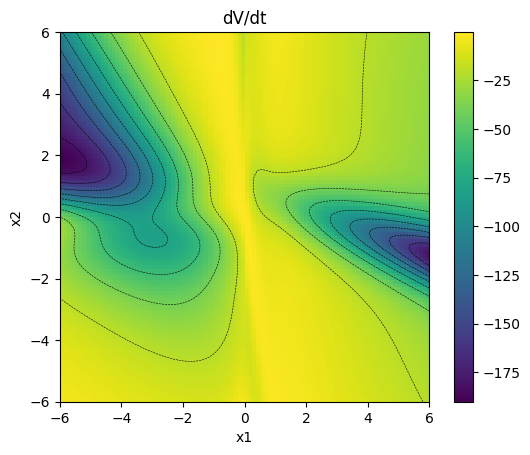

In [158]:
plt.imshow(L_plot, extent=[-6, 6, -6, 6], origin='lower')
plt.colorbar(cmap=cm.coolwarm)
plt.title('dV/dt')
plt.xlabel('x1')
plt.ylabel('x2')
# plt.xticks(ticks=range(100), labels=X)
plt.contour(x1,x2,L_plot,10,linewidths=0.4, colors='k')
plt.show()

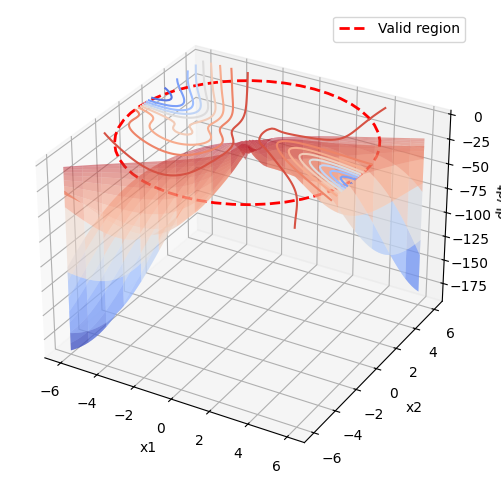

In [105]:

fig = plt.figure(figsize=(6, 6))
plt.tight_layout()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X,Y,L_plot, rstride=5, cstride=5, alpha=0.5, cmap=cm.coolwarm)
ax.contour(X,Y,L_plot,10, zdir='z', offset=0, cmap=cm.coolwarm)

# Plot Valid region computed by dReal
r=6
theta = np.linspace(0,2*np.pi,50)
xc = r*np.cos(theta)
yc = r*np.sin(theta)
ax.plot(xc[:],yc[:],'r',linestyle='--', linewidth=2 ,label='Valid region')
plt.legend(loc='upper right')
plt.xlabel('x1')
plt.ylabel('x2')
ax.set_zlabel('dL/dt')
# fig.subplots_adjust(left=0.1, right=150, bottom=0.1, top=1)
plt.show()

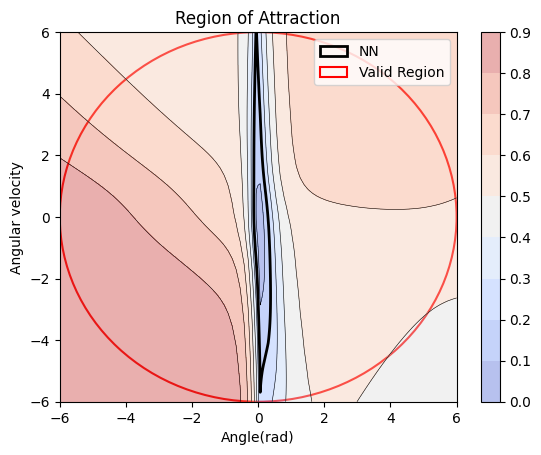

In [128]:
# plot ROA
# def Plotflow(Xd, Yd, t):
#     # Plot phase plane 
#     DX, DY = f([Xd, Yd],t)
#     DX=DX/np.linalg.norm(DX, ord=2, axis=1, keepdims=True)
#     DY=DY/np.linalg.norm(DY, ord=2, axis=1, keepdims=True)
#     plt.streamplot(Xd,Yd,DX,DY, color=('gray'), linewidth=0.5,
#                   density=0.5, arrowstyle='-|>', arrowsize=1.5)
    

# def f(y,t) :
#     #parameters
#     G = 9.81 
#     L = 0.5  
#     m = 0.15  
#     b = 0.1   
#     x1,x2 = y    
#     Ku = np.matrix([[-23.586397, -5.314206]])
#     u = (Ku.item(0)*x1 + Ku.item(1)*x2)
#     dydt =[x2,  (m*G*L*sin(x1) + u - b*x2) / (m*L**2)]
#     return dydt

ax = plt.gca()

# Lyapunov functions
# V_SOS = x1**6*(2.11*x1**6 + 0.006847*x1**5*x2 + 0.0937*x1**4*x2**2 - 6.223e-8*x1**3*x2**3 - 1.307e-9*x1**2*x2**4 - 5.609e-9*x1**2 - 3.692e-9*x1*x2**5 - 5.893e-10*x2**6 + 2.132e-9*x2**2) + x1**5*x2*(0.006847*x1**6 + 0.0937*x1**5*x2 - 0.0271*x1**4*x2**2 - 1.307e-9*x1**3*x2**3 - 3.692e-9*x1**2*x2**4 + 2.132e-9*x1**2 - 5.893e-10*x1*x2**5 + 4.724e-10*x2**6 + 6.079e-10*x2**2) + x1**4*x2**2*(0.0937*x1**6 - 0.0271*x1**5*x2 + 0.03769*x1**4*x2**2 - 3.692e-9*x1**3*x2**3 - 5.893e-10*x1**2*x2**4 + 6.079e-10*x1**2 + 4.724e-10*x1*x2**5 + 2.836e-10*x2**6 + 1.731e-9*x2**2) + x1**3*x2**3*(-6.223e-8*x1**6 - 1.307e-9*x1**5*x2 - 3.692e-9*x1**4*x2**2 + 5.913*x1**3*x2**3 + 0.2135*x1**2*x2**4 + 2.11*x1**2 + 0.1824*x1*x2**5 + 0.009201*x2**6 + 0.006847*x2**2) + x1**2*x2**4*(-1.307e-9*x1**6 - 3.692e-9*x1**5*x2 - 5.893e-10*x1**4*x2**2 + 0.2135*x1**3*x2**3 + 0.1824*x1**2*x2**4 + 0.006847*x1**2 + 0.009201*x1*x2**5 + 0.01684*x2**6 + 0.0937*x2**2) + x1**2*(-5.609e-9*x1**6 + 2.132e-9*x1**5*x2 + 6.079e-10*x1**4*x2**2 + 2.11*x1**3*x2**3 + 0.006847*x1**2*x2**4 + 4.09*x1**2 + 0.0937*x1*x2**5 - 0.0271*x2**6 + 0.09225*x2**2) + x1*x2**5*(-3.692e-9*x1**6 - 5.893e-10*x1**5*x2 + 4.724e-10*x1**4*x2**2 + 0.1824*x1**3*x2**3 + 0.009201*x1**2*x2**4 + 0.0937*x1**2 + 0.01684*x1*x2**5 + 0.02061*x2**6 - 0.0271*x2**2) + x2**6*(-5.893e-10*x1**6 + 4.724e-10*x1**5*x2 + 2.836e-10*x1**4*x2**2 + 0.009201*x1**3*x2**3 + 0.01684*x1**2*x2**4 - 0.0271*x1**2 + 0.02061*x1*x2**5 + 0.01081*x2**6 + 0.03769*x2**2) + x2**2*(2.132e-9*x1**6 + 6.079e-10*x1**5*x2 + 1.731e-9*x1**4*x2**2 + 0.006847*x1**3*x2**3 + 0.0937*x1**2*x2**4 + 0.09225*x1**2 - 0.0271*x1*x2**5 + 0.03769*x2**6 + 0.2055*x2**2) - 17.0341495901499
V_lqr = 85.5250*x1**2 + 2*14.1518*x1*x2 + 2.4269*x2**2 #narrow
# V = tanh((0.1592191 + 0.6047373* tanh((-1.2250961 - 1.1751087 * x1 + 0.028802002 * x2)) - 0.69419956 * tanh((-0.81576663 + 0.02652748* x1 - 0.00072127824999999998 * x2)) - 1.1177092 * tanh((-0.53083205 + 0.043899357 * x1 - 0.0029811477000000002 * x2)) - 1.1329674000000001 * tanh((0.89248989999999995 - 0.55178492999999995 * x1 - 0.034781724 * x2)) + 0.77995585999999995 * tanh((0.93392560000000002 - 0.0067463684999999997 * x1 - 0.0067418180000000001 * x2)) - 0.26213419999999998 * tanh((1.0895116 + 0.44463265000000002 * x1 + 0.2598702 * x2))))-0.212

# Vaild Region
C = plt.Circle((0, 0),6, color='r', linewidth=1.5, fill=False)
ax.add_artist(C)

# # plot direction field
# xd = np.linspace(-6, 6, 10) 
# yd = np.linspace(-6, 6, 10)
# Xd, Yd = np.meshgrid(xd,yd)
# t = np.linspace(0,2,100)
# Plotflow(Xd, Yd, t) 


ax.contour(X,Y,V_plot-1.2,0,linewidths=2, colors='k', linestyles='-')
# ax.contour(X,Y,V_lqr-2.6,0,linewidths=2, colors='m',linestyles='--')
# ax.contour(X,Y,V_SOS,0,linewidths=2, colors='b')


ax.contour(x1,x2,V_plot,8,linewidths=0.4, colors='k')
c1 = ax.contourf(x1,x2,V_plot,8,alpha=0.4,cmap=cm.coolwarm)
plt.colorbar(c1)

plt.title('Region of Attraction')
plt.legend([plt.Rectangle((0,0),1,2,color='k',fill=False,linewidth = 2),C]\
           ,['NN','Valid Region'],loc='upper right')
# plt.legend(['NN','Valid Region'],loc='upper right')
plt.xlabel('Angle(rad)')
plt.ylabel('Angular velocity')
plt.show()

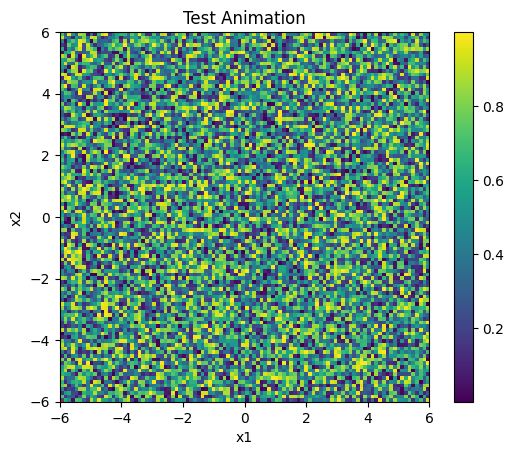

In [153]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

# Dummy data: list of 2D arrays (e.g. 20 frames of 100x100 heatmaps)
frames = [np.random.rand(100, 100) for _ in range(20)]

vmin = np.min(frames)
vmax = np.max(frames)

scatter_i = np.linspace(-6, 6, 20)
fig, ax = plt.subplots()
# im = ax.imshow(frames[0], cmap='viridis', origin='lower', animated=True)
im = ax.imshow(frames[0], cmap='viridis', origin='lower', vmin=vmin, vmax=vmax, animated=True, extent=[-6, 6, -6, 6])
sc = ax.scatter(scatter_i[0], scatter_i[0], color='red', s=30, marker='.')

cbar = fig.colorbar(im, ax=ax) 
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_title('Test Animation')

# Update function
def update(frame):
    im.set_array(frames[frame])
    sc.set_offsets(np.c_[scatter_i[:frame], scatter_i[:frame]]) 
    return [im, sc]

# Create animation
ani = animation.FuncAnimation(
    fig, update, frames=len(frames), interval=100, blit=False
)
# plt.colorbar()
plt.show()
ani.save('animation_test.mp4', writer='ffmpeg')

In [160]:
V_load = np.load('export/lyapunov_function.npy')

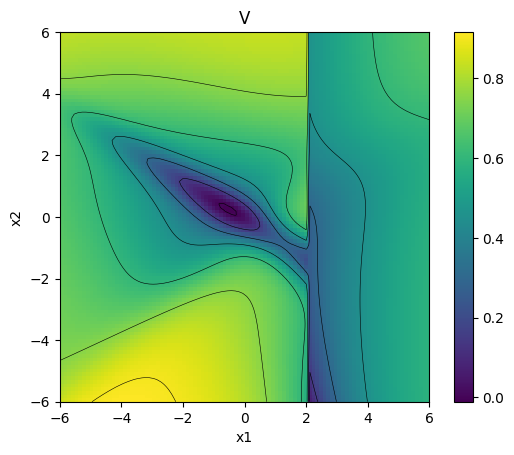

In [162]:
plt.imshow(V_load, extent=[-6, 6, -6, 6], origin='lower')
plt.colorbar(cmap=cm.coolwarm)
plt.title('V')
plt.xlabel('x1')
plt.ylabel('x2')
# plt.xticks(ticks=range(100), labels=X)
plt.contour(x1,x2,V_load,8,linewidths=0.4, colors='k')
plt.show()